# stc tv | Task 2: Forecast daily watch time

**Goal.** Build a simple forecast for the next two calendar months and identify likely peak dates. The supplied workbook contains **daily total watch hours**, not a count of viewing events. This notebook therefore forecasts watch hours. A view-count forecast would require a daily view-count column.

**Data source.** [stc TV Data Set_T2.xlsx](https://docs.google.com/spreadsheets/d/1ef5VbBgvzq7x7d833PvjhrVYMcr1pcjh/edit?gid=1631780481), sheet `Sheet1`, supplied with the virtual work experience. Run the cells in order in Google Colab or Jupyter. If the workbook is not beside the notebook, the first code cell asks you to upload it in Colab.

## 1. Load and inspect the data

In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

try:
    import openpyxl
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'openpyxl'])

DATA_FILE = Path('stc TV Data Set_T2.xlsx')
if not DATA_FILE.exists():
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError(f'Place {DATA_FILE.name} beside this notebook.') from exc
    print(f'Please upload {DATA_FILE.name}.')
    files.upload()

if not DATA_FILE.exists():
    raise FileNotFoundError(f'{DATA_FILE.name} was not uploaded.')

raw = pd.read_excel(DATA_FILE, sheet_name='Sheet1')
print(f'Rows: {raw.shape[0]}; columns: {raw.shape[1]}')
display(raw.head())

Rows: 86; columns: 3


,Unnamed: 0,date_,Total_watch_time_in_houres
0,0,2018-01-01,1123.551944
1,1,2018-01-02,1000.129722
2,2,2018-01-03,881.924444
3,3,2018-01-04,782.669444
4,4,2018-01-05,1051.939444


## 2. Prepare the daily series

Remove the exported row index, parse dates, check for missing values and duplicate dates, and verify that the source contains business days only. The dataset ends on 30 April 2018.

In [2]:
df = raw[['date_', 'Total_watch_time_in_houres']].copy()
df = df.rename(columns={'Total_watch_time_in_houres': 'watch_hours'})
df['date_'] = pd.to_datetime(df['date_'], errors='coerce')
df['watch_hours'] = pd.to_numeric(df['watch_hours'], errors='coerce')
df = df.sort_values('date_').reset_index(drop=True)
missing = df.isna().sum()
duplicate_dates = df['date_'].duplicated().sum()
expected_days = pd.bdate_range(df['date_'].min(), df['date_'].max())
missing_business_days = expected_days.difference(df['date_'])
print('Missing values:', missing.to_dict())
print('Duplicate dates:', duplicate_dates)
print('Missing business days:', len(missing_business_days))
print('Observed period:', df['date_'].min().date(), 'to', df['date_'].max().date())
assert missing.sum() == 0 and duplicate_dates == 0
assert len(missing_business_days) == 0 and len(df) == len(expected_days)
assert (df['watch_hours'] >= 0).all()
display(df['watch_hours'].describe().loc[['count', 'mean', 'std', 'min', 'max']].to_frame())

Missing values: {'date_': 0, 'watch_hours': 0}
Duplicate dates: 0
Missing business days: 0
Observed period: 2018-01-01 to 2018-04-30


,watch_hours
count,86.000000
mean,780.817926
std,122.992002
min,562.124722
max,1123.551944


## 3. Explore the trend and possible weekly peaks

The data decline over the four observed months. Weekday averages are included to check for a repeatable peak, but their differences are small relative to daily variation.

Monthly history:


,count,mean,sum
date_,,,
2018-01,23,866.57,19931.02
2018-02,20,823.46,16469.29
2018-03,22,754.65,16602.28
2018-04,21,673.70,14147.75


Weekday history:


,count,mean,std
date_,,,
Monday,18,790.17,138.54
Tuesday,17,785.23,122.42
Wednesday,17,766.28,121.66
Thursday,17,767.93,115.84
Friday,17,793.92,126.73


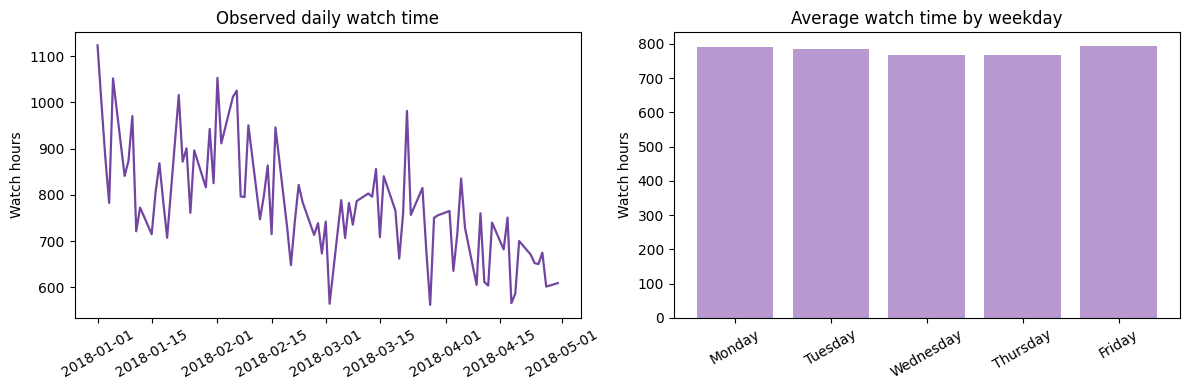

In [3]:
monthly_history = (df.groupby(df['date_'].dt.to_period('M'))['watch_hours']
                     .agg(['count', 'mean', 'sum']))
weekday_history = (df.groupby(df['date_'].dt.day_name())['watch_hours']
                     .agg(['count', 'mean', 'std'])
                     .reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']))
print('Monthly history:')
display(monthly_history.round(2))
print('Weekday history:')
display(weekday_history.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df['date_'], df['watch_hours'], color='#7145A0', linewidth=1.6)
axes[0].set_title('Observed daily watch time')
axes[0].set_ylabel('Watch hours')
axes[0].tick_params(axis='x', rotation=30)
axes[1].bar(weekday_history.index, weekday_history['mean'], color='#B89AD0')
axes[1].set_title('Average watch time by weekday')
axes[1].set_ylabel('Watch hours')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 4. Validate a simple forecasting model

Use **linear regression on the business-day number**. A chronological holdout of the last 44 business days simulates the length of the May–June forecast. Compare it with a simple baseline that repeats the last observed week. Mean absolute error (MAE) is the average error in watch hours per day.

Linear trend MAE: 63.72 hours/day
Last-week baseline MAE: 85.86 hours/day
Linear trend MAPE: 8.99%


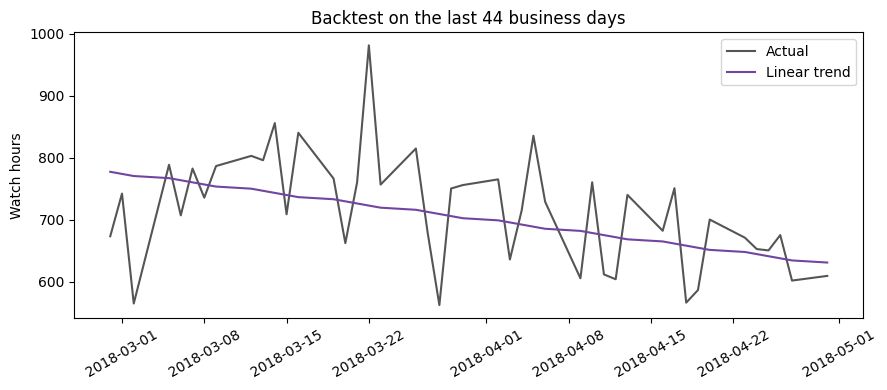

In [4]:
df['business_day_number'] = np.arange(len(df))
validation_days = 44
train = df.iloc[:-validation_days].copy()
validation = df.iloc[-validation_days:].copy()
model = LinearRegression()
model.fit(train[['business_day_number']], train['watch_hours'])
validation['predicted_hours'] = model.predict(validation[['business_day_number']])
validation['last_week_baseline'] = np.resize(train['watch_hours'].tail(5).to_numpy(),
                                              len(validation))
model_mae = mean_absolute_error(validation['watch_hours'], validation['predicted_hours'])
baseline_mae = mean_absolute_error(validation['watch_hours'],
                                   validation['last_week_baseline'])
model_mape = (100 * np.mean(np.abs(validation['watch_hours']
                                  - validation['predicted_hours'])
                                  / validation['watch_hours']))
print(f'Linear trend MAE: {model_mae:.2f} hours/day')
print(f'Last-week baseline MAE: {baseline_mae:.2f} hours/day')
print(f'Linear trend MAPE: {model_mape:.2f}%')
assert model_mae < baseline_mae

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(validation['date_'], validation['watch_hours'], label='Actual', color='#555555')
ax.plot(validation['date_'], validation['predicted_hours'], label='Linear trend',
        color='#7145A0')
ax.set_title('Backtest on the last 44 business days')
ax.set_ylabel('Watch hours')
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 5. Forecast the next two calendar months

Refit the selected model using all 86 observed business days. Forecast May and June 2018 on the same Monday–Friday schedule as the source. Weekends are not estimated because the workbook has no weekend observations.

Forecast period: 2018-05-01 to 2018-06-30
Forecast business days: 44
Estimated change per business day: -3.18 hours


,date_,expected_watch_hours
0,2018-05-01,642.52
1,2018-05-02,639.34
2,2018-05-03,636.16
3,2018-05-04,632.98
4,2018-05-07,629.80
5,2018-05-08,626.62
6,2018-05-09,623.44
7,2018-05-10,620.26
8,2018-05-11,617.08
9,2018-05-14,613.91


Forecast by month:


,count,sum,mean
date_,,,
2018-05,23,13973.58,607.55
2018-06,21,11289.66,537.60


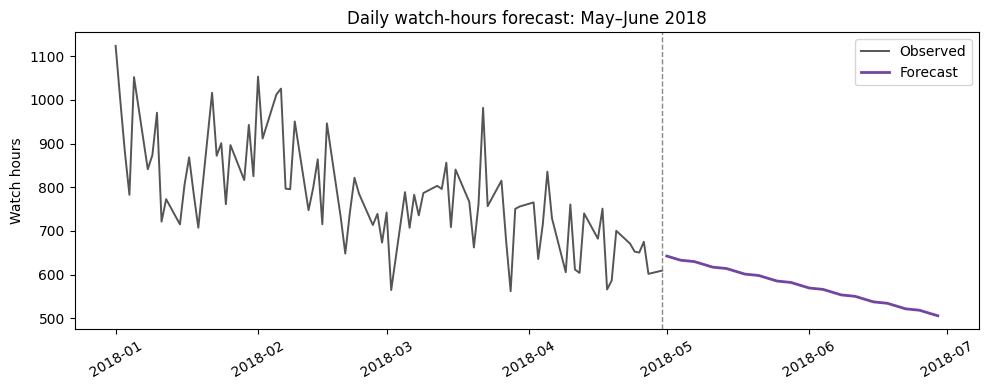

In [5]:
final_model = LinearRegression()
final_model.fit(df[['business_day_number']], df['watch_hours'])
forecast_start = df['date_'].max() + pd.offsets.MonthBegin(1)
forecast_end = forecast_start + pd.DateOffset(months=2) - pd.Timedelta(days=1)
future_dates = pd.bdate_range(forecast_start, forecast_end)
forecast = pd.DataFrame({'date_': future_dates,
                         'business_day_number': np.arange(
                             len(df), len(df) + len(future_dates))})
forecast['expected_watch_hours'] = final_model.predict(
    forecast[['business_day_number']])
assert (forecast['expected_watch_hours'] >= 0).all()
print(f'Forecast period: {forecast_start.date()} to {forecast_end.date()}')
print(f'Forecast business days: {len(forecast)}')
print(f'Estimated change per business day: {final_model.coef_[0]:.2f} hours')
display(forecast[['date_', 'expected_watch_hours']].head(10).round(
    {'expected_watch_hours': 2}))

monthly_forecast = (forecast.groupby(forecast['date_'].dt.to_period('M'))
                    ['expected_watch_hours'].agg(['count', 'sum', 'mean']))
print('Forecast by month:')
display(monthly_forecast.round(2))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df['date_'], df['watch_hours'], label='Observed', color='#555555',
        linewidth=1.4)
ax.plot(forecast['date_'], forecast['expected_watch_hours'],
        label='Forecast', color='#7145A0', linewidth=2)
ax.axvline(df['date_'].max(), color='#888888', linestyle='--', linewidth=1)
ax.set_title('Daily watch-hours forecast: May–June 2018')
ax.set_ylabel('Watch hours')
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 6. Identify likely peak dates

The forecast has a downward trend, so its highest dates are at the start of May. This is a forecast of **daily totals**; hourly peak times cannot be identified from this workbook.

In [6]:
peak_dates = forecast.nlargest(5, 'expected_watch_hours')[
    ['date_', 'expected_watch_hours']].copy()
peak_dates['weekday'] = peak_dates['date_'].dt.day_name()
display(peak_dates[['date_', 'weekday', 'expected_watch_hours']].round(
    {'expected_watch_hours': 2}))
best_day = peak_dates.iloc[0]
print(f"Highest expected day: {best_day['date_'].date()} ({best_day['expected_watch_hours']:.1f} hours)")

,date_,weekday,expected_watch_hours
0,2018-05-01,Tuesday,642.52
1,2018-05-02,Wednesday,639.34
2,2018-05-03,Thursday,636.16
3,2018-05-04,Friday,632.98
4,2018-05-07,Monday,629.80


Highest expected day: 2018-05-01 (642.5 hours)


## 7. Decision summary and limitations

- The workbook contains **86 business-day records** from 1 January to 30 April 2018, with no missing values or business dates. Average daily watch time falls from **866.6 hours in January** to **673.7 hours in April**.
- The simple linear trend model has **63.7 hours/day MAE** on a 44-business-day holdout, compared with **85.9 hours/day** for repeating the last observed week. This backtest is informative, but the next two months may behave differently.
- The model forecasts approximately **13,974 watch hours in May 2018** and **11,290 watch hours in June 2018**. The highest expected date is **1 May 2018**, at approximately **643 hours**. Plan for relatively higher capacity in early May.
- The observed weekday averages differ little compared with day-to-day variation, so the model does not claim a reliable recurring weekday peak.

**Limits.** The model extrapolates a four-month downward trend and has no holiday, promotion, or content-release information. It predicts watch hours rather than the number of views, and it cannot identify hours of the day or forecast weekends. Use the forecast as a planning estimate, then update it when newer data arrive.